In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from service import SeattleBuildingService

In [2]:
service = SeattleBuildingService()

In [3]:
#df_esti = pd.read_json('./data/projet6_estimation.json' , orient = "records")
df_esti = pd.read_csv('./data/projet6_estimation.csv')

In [4]:
predictions = service.predict (df_esti)

#predictions = np.expm1 (predictions_log) 

data_test = df_esti.copy()
data_test["prediction"] = predictions



In [5]:
data_test["TotalGHGEmissions"].describe()

count     85.000000
mean      82.767176
std       79.978549
min        2.340000
25%       30.220000
50%       56.820000
75%       94.640000
max      359.090000
Name: TotalGHGEmissions, dtype: float64

In [6]:
data_test["prediction"].describe()

count     85.000000
mean      92.690328
std       79.016166
min        2.498207
25%       40.100817
50%       67.740823
75%      117.283622
max      317.349809
Name: prediction, dtype: float64

In [7]:
# Total cumulé réels vs prédits
total_reel = data_test["TotalGHGEmissions"].sum()
total_predit = data_test["prediction"].sum()
ratio_global_pct = (total_predit / total_reel) * 100
# Erreur Pourcentage Moyenne Absolue (MAPE)

mape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).mean()
    * 100
)

# Erreur Médiane Pourcentage Absolue (MdAPE) - Résistante aux valeurs aberrantes
mdape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).median()
    * 100
)

# 5. Affichage des résultats
print(f"--- RÉSULTATS GLOBAUX DU MODÈLE ---")
print(
    f"Volume réel total      : {total_reel:,.2f} tCO2e"
)
print(
    f"Volume prédit total     : {total_predit:,.2f} tCO2e"
)
print(
    f"Ratio global de volume  : {ratio_global_pct:.2f}% "
)
print(f"Erreur moyenne (MAPE)   : {mape:.2f}%")
print(f"Erreur médiane (MdAPE)  : {mdape:.2f}%")

--- RÉSULTATS GLOBAUX DU MODÈLE ---
Volume réel total      : 7,035.21 tCO2e
Volume prédit total     : 7,878.68 tCO2e
Ratio global de volume  : 111.99% 
Erreur moyenne (MAPE)   : 26.37%
Erreur médiane (MdAPE)  : 20.99%


In [8]:
data_test["ecart"] =data_test["TotalGHGEmissions"] - data_test["prediction"] 

data_test["ratio_pct"] = ( data_test["prediction"]/ data_test["TotalGHGEmissions"]) *100

data_test["ratio_erreur_pct"] = (
    (data_test["prediction"] - data_test["TotalGHGEmissions"])
    / data_test["TotalGHGEmissions"]
) * 100

In [9]:
display (data_test[["BuildingType", "ENERGYSTARScore","TotalGHGEmissions" ,"prediction", "ecart", "ratio_pct" , "ratio_erreur_pct", "BuildingAge"] ].sort_values(by ="BuildingAge"))

,BuildingType,ENERGYSTARScore,TotalGHGEmissions,prediction,ecart,ratio_pct,ratio_erreur_pct,BuildingAge
20,SPS-District K-12,75.0,80.08,141.471834,-61.391834,176.663129,76.663129,6
81,SPS-District K-12,84.0,124.77,171.130618,-46.360618,137.156863,37.156863,7
50,SPS-District K-12,77.0,24.42,27.752033,-3.332033,113.644688,13.644688,8
9,SPS-District K-12,60.0,359.09,278.258683,80.831317,77.489956,-22.510044,8
33,SPS-District K-12,94.0,226.06,171.472231,54.587769,75.852531,-24.147469,9
...,...,...,...,...,...,...,...,...
67,SPS-District K-12,92.0,94.85,117.283622,-22.433622,123.651684,23.651684,91
69,SPS-District K-12,85.0,69.18,86.553100,-17.373100,125.112893,25.112893,91
34,NonResidential,71.0,148.11,147.388455,0.721545,99.512832,-0.487168,95
35,NonResidential,83.0,22.39,16.694353,5.695647,74.561650,-25.438350,107


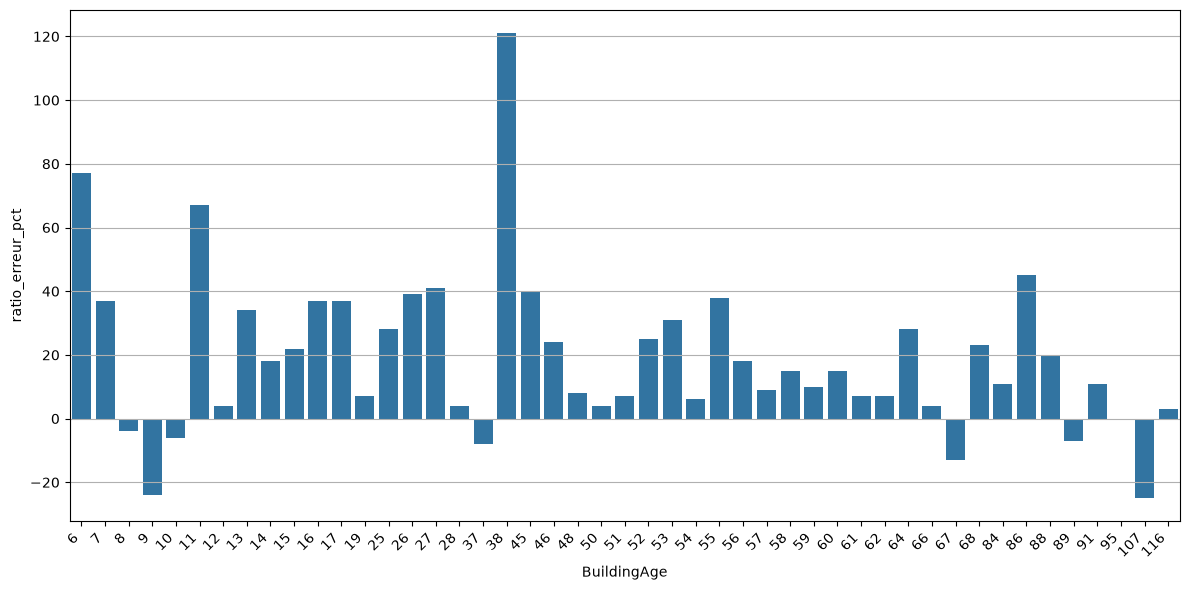

In [10]:
plt.figure(figsize=(12,6))
consommation_par_type = data_test.groupby('BuildingAge')['ratio_erreur_pct'].mean().sort_values(ascending=True).round(0)
sns.barplot(data=consommation_par_type)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y')
plt.tight_layout()